# PJM Grid Demand Forecasting
Three models, increasing complexity:
1. **Persistence baseline** — same hour last week
2. **SARIMAX** — statsmodels, daily aggregates + temperature
3. **XGBoost** — full feature matrix
4. **LSTM** — sliding 168-hour window

Metric: **MAPE** (mean absolute percentage error) and **RMSE**

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
from google.colab import drive
from google.colab import drive
drive.mount('/content/drive')
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


# Step by step check



Mounted at /content/drive


## 1. Load Data

In [ ]:
DATA = '/content/drive/MyDrive/Machine Learning Project/pjm_grid/data/processed'
print(DATA)

train = pd.read_csv(f'{DATA}/pjm_train.csv', parse_dates=['datetime_utc'])
val   = pd.read_csv(f'{DATA}/pjm_val.csv',   parse_dates=['datetime_utc'])
test  = pd.read_csv(f'{DATA}/pjm_test.csv',  parse_dates=['datetime_utc'])

# Feature columns (everything except timestamp and target)
TARGET = 'demand_mw'
FEATURES = [c for c in train.columns if c not in ['datetime_utc', TARGET]]

print(f'Train: {len(train):,} rows  ({train.datetime_utc.min().date()} → {train.datetime_utc.max().date()})')
print(f'Val:   {len(val):,} rows  ({val.datetime_utc.min().date()} → {val.datetime_utc.max().date()})')
print(f'Test:  {len(test):,} rows  ({test.datetime_utc.min().date()} → {test.datetime_utc.max().date()})')
print(f'\nFeatures ({len(FEATURES)}): {FEATURES}')

/content/drive/MyDrive/Machine Learning Project/pjm_grid/data/processed
Train: 30,498 rows  (2020-01-08 → 2023-07-04)
Val:   6,536 rows  (2023-07-04 → 2024-04-02)
Test:  6,536 rows  (2024-04-02 → 2024-12-31)

Features (23): ['temp_f', 'humidity_pct', 'wind_mph', 'cloud_pct', 'precip_in', 'hdd', 'cdd', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'wind_chill_f', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'temp_lag_24h', 'demand_rolling_24h_mean', 'temp_rolling_24h_mean', 'sin_year', 'cos_year', 'sin_half_year', 'cos_half_year']


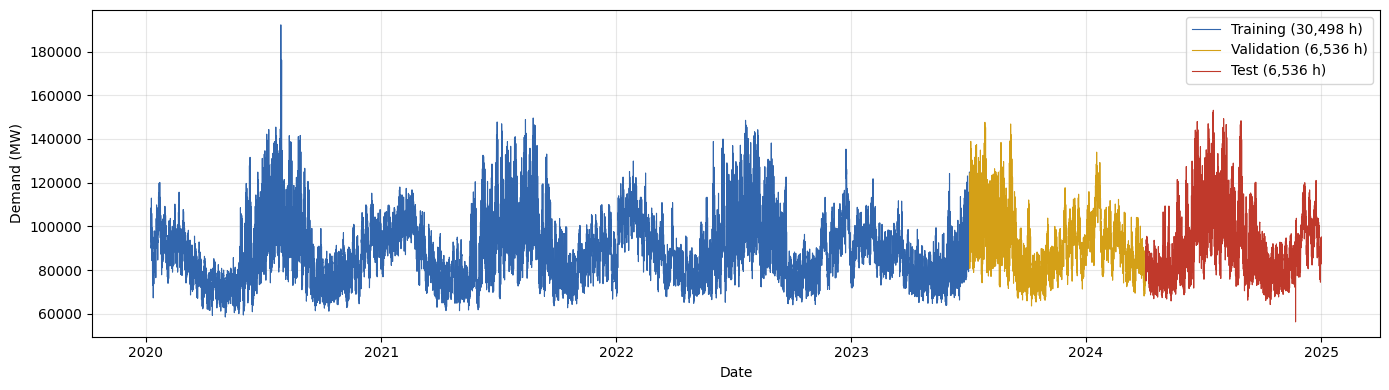

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train['datetime_utc'], train['demand_mw'], color='#3266ad', linewidth=0.8, label=f'Training ({len(train):,} h)')
ax.plot(val['datetime_utc'],   val['demand_mw'],   color='#d4a017', linewidth=0.8, label=f'Validation ({len(val):,} h)')
ax.plot(test['datetime_utc'],  test['demand_mw'],  color='#c0392b', linewidth=0.8, label=f'Test ({len(test):,} h)')

ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig2_split.png', dpi=150)
plt.show()

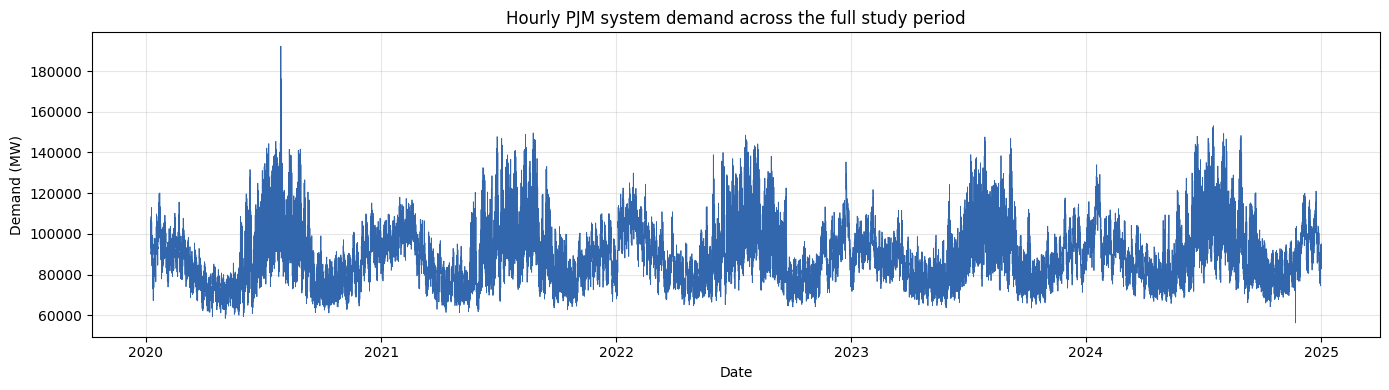

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Concatenate all splits in order
all_data = pd.concat([train, val, test], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(all_data['datetime_utc'], all_data['demand_mw'], color='#3266ad', linewidth=0.6)

ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
ax.set_title('Hourly PJM system demand across the full study period')
plt.tight_layout()
plt.savefig('fig1_full_series.png', dpi=150)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1b. Feature Augmentation
Add day-ahead demand forecast and COVID flag to all splits.

In [ ]:
# Day-ahead forecast (from EIA-930 raw data)
raw_demand = pd.read_csv('/content/drive/MyDrive/data/processed/pjm_hourly_demand.csv',
                          parse_dates=['datetime_utc'])
forecast_col = pd.to_numeric(raw_demand['Demand Forecast (MW)'], errors='coerce')
raw_forecast = pd.DataFrame({'datetime_utc': raw_demand['datetime_utc'],
                              'demand_forecast_mw': forecast_col})

train = train.merge(raw_forecast, on='datetime_utc', how='left')
val   = val.merge(raw_forecast,   on='datetime_utc', how='left')
test  = test.merge(raw_forecast,  on='datetime_utc', how='left')

# Fill the 143 NaN forecast values via forward-fill (time-series safe)
for df in [train, val, test]:
    df['demand_forecast_mw'] = df['demand_forecast_mw'].ffill().bfill()

# COVID demand suppression flag (March 2020 - June 2021)
for df in [train, val, test]:
    df['is_covid'] = ((df['datetime_utc'] >= '2020-03-01') &
                      (df['datetime_utc'] <= '2021-06-30')).astype(int)


# Interaction features: captures non-linear demand-temperature relationship
for df in [train, val, test]:
   # df["lag1h_x_temp"]  = df["demand_lag_1h"]  * df["temp_f"]
    df["lag24h_x_hdd"] = df["demand_lag_24h"] * df["hdd"]
    df["lag24h_x_cdd"] = df["demand_lag_24h"] * df["cdd"]

# Rebuild FEATURES to include new columns
FEATURES = [c for c in train.columns if c not in ['datetime_utc', TARGET]]

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Forecast NaN after fill: {train["demand_forecast_mw"].isna().sum()}')
print(f'COVID hours in train:    {train["is_covid"].sum():,}')


Features (27): ['temp_f', 'humidity_pct', 'wind_mph', 'cloud_pct', 'precip_in', 'hdd', 'cdd', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'wind_chill_f', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'temp_lag_24h', 'demand_rolling_24h_mean', 'temp_rolling_24h_mean', 'sin_year', 'cos_year', 'sin_half_year', 'cos_half_year', 'demand_forecast_mw', 'is_covid', 'lag24h_x_hdd', 'lag24h_x_cdd']
Forecast NaN after fill: 0
COVID hours in train:    11,631


## 2. Quick EDA

## Helper: Metrics

In [ ]:
def evaluate(name, y_true, y_pred, split='test'):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'[{name}] {split:5s}  MAPE={mape:.2f}%  RMSE={rmse:,.0f} MW  MAE={mae:,.0f} MW')
    return {'model': name, 'split': split, 'MAPE': mape, 'RMSE': rmse, 'MAE': mae, 'R2' : r2}

results = []

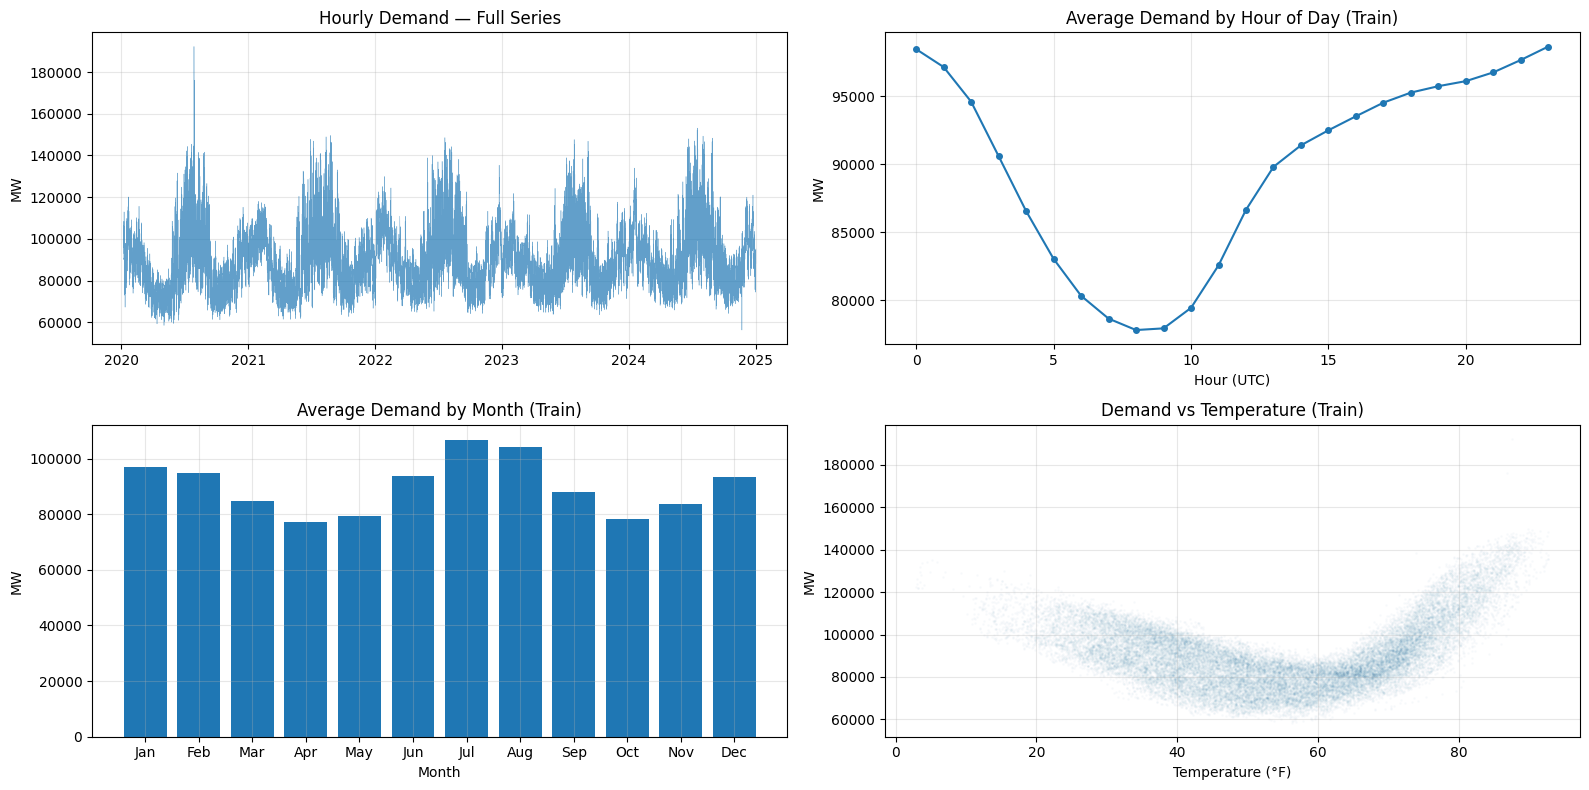

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Full demand series
all_data = pd.concat([train, val, test])
axes[0,0].plot(all_data['datetime_utc'], all_data[TARGET], lw=0.3, alpha=0.7)
axes[0,0].set_title('Hourly Demand — Full Series')
axes[0,0].set_ylabel('MW')

# Average by hour of day
hourly_avg = train.groupby('hour')[TARGET].mean()
axes[0,1].plot(hourly_avg.index, hourly_avg.values, marker='o', ms=4)
axes[0,1].set_title('Average Demand by Hour of Day (Train)')
axes[0,1].set_xlabel('Hour (UTC)')
axes[0,1].set_ylabel('MW')

# Average by month
monthly_avg = train.groupby('month')[TARGET].mean()
axes[1,0].bar(monthly_avg.index, monthly_avg.values)
axes[1,0].set_title('Average Demand by Month (Train)')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('MW')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

# Demand vs temperature
axes[1,1].scatter(train['temp_f'], train[TARGET], alpha=0.02, s=1)
axes[1,1].set_title('Demand vs Temperature (Train)')
axes[1,1].set_xlabel('Temperature (°F)')
axes[1,1].set_ylabel('MW')

plt.tight_layout()
plt.show()

[Persistence] val    MAPE=8.61%  RMSE=10,842 MW  MAE=8,066 MW
[Persistence] test   MAPE=9.12%  RMSE=12,222 MW  MAE=8,828 MW


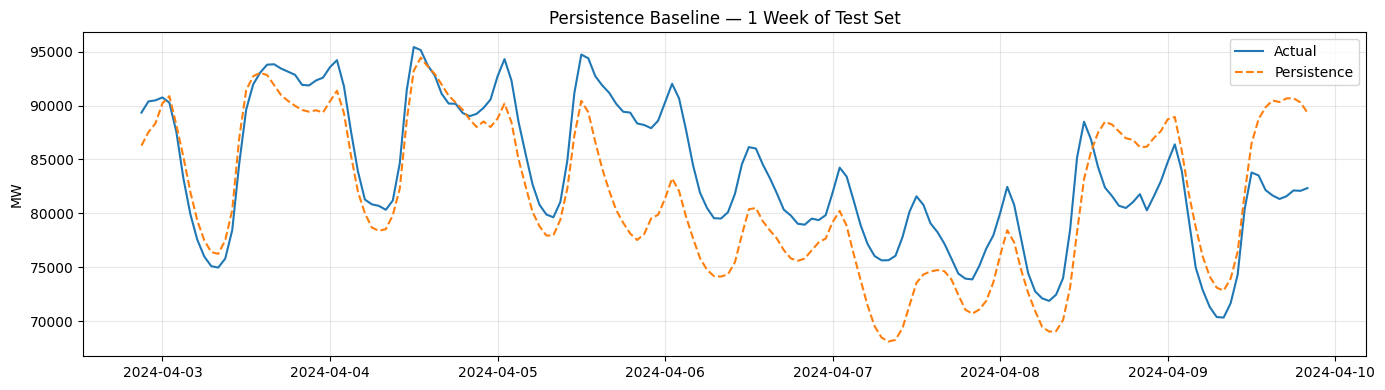

In [ ]:
for split_name, split_df in [('val', val), ('test', test)]:
    y_true = split_df[TARGET].values
    y_pred = split_df['demand_lag_168h'].values
    results.append(evaluate('Persistence', y_true, y_pred, split_name))

# Plot one week of test predictions
sample = test.iloc[:168].copy()
plt.figure()
plt.plot(sample['datetime_utc'], sample[TARGET], label='Actual', lw=1.5)
plt.plot(sample['datetime_utc'], sample['demand_lag_168h'], label='Persistence', lw=1.5, ls='--')
plt.title('Persistence Baseline — 1 Week of Test Set')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Baseline — Persistence (Same Hour Last Week)
Predict hour `t` using the observed demand from `t - 168h`.  
This is already in the dataset as `demand_lag_168h`.

## 4. SARIMAX
Fit on **daily** average demand to keep it tractable (~1,800 training days).  
Order: (1,1,2) × (1,1,1,7) — AR/MA terms plus weekly seasonality.  
Exogenous: daily average temperature.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


def to_daily(df):
    return df.set_index('datetime_utc').resample('D').agg(
        demand_mw=('demand_mw', 'mean'),
        temp_f=('temp_f', 'mean'),
        hdd=('hdd', 'sum'),
        cdd=('cdd', 'sum'),
    ).dropna().asfreq('D')

train_d = to_daily(train)
val_d   = to_daily(val)
test_d  = to_daily(test)

print(f'Daily train: {len(train_d)} days, val: {len(val_d)} days, test: {len(test_d)} days')
print("Fitting SARIMAX(1,0,1)(2,1,1,7)")
exog_cols = ["temp_f", "hdd", "cdd"]
sarimax_model = SARIMAX(
    train_d["demand_mw"],
    exog=train_d[exog_cols],
    order=(1, 0, 1),
    seasonal_order=(2, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("Done.")
print(sarimax_model.summary().tables[0])

Daily train: 1274 days, val: 274 days, test: 274 days
Fitting SARIMAX(1,0,1)(2,1,1,7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Done.
                                     SARIMAX Results                                     
Dep. Variable:                         demand_mw   No. Observations:                 1274
Model:             SARIMAX(1, 0, 1)x(2, 1, 1, 7)   Log Likelihood              -11828.925
Date:                           Mon, 27 Apr 2026   AIC                          23675.850
Time:                                   21:57:40   BIC                          23722.043
Sample:                               01-08-2020   HQIC                         23693.214
                                    - 07-04-2023                                         
Covariance Type:                             opg                                         


### 4a. SARIMAX Order Selection via AIC/BIC
AIC/BIC compare models **within the same family** (different ARIMA orders).
Lower is better. We test 4 candidate orders to confirm (1,1,1)x(1,1,1,7) is optimal.

In [ ]:
print("Comparing SARIMAX orders by AIC/BIC (fits 4 models)...")

candidate_orders = [
    ((1,1,1), (1,1,1,7), "(1,1,1)x(1,1,1,7)"),
    ((2,1,1), (1,1,1,7), "(2,1,1)x(1,1,1,7)"),
    ((1,0,1), (2,1,1,7), "(1,0,1)x(2,1,1,7)"),
    ((2,1,2), (1,1,1,7), "(2,1,2)x(1,1,1,7)"),
    ((1,1,1), (0,1,1,7), "(1,1,1)x(0,1,1,7)"),
    ((1,1,1), (2,1,1,7), "(1,1,1)x(2,1,1,7)"),
]

aic_bic_results = []
for order, seasonal_order, label in candidate_orders:
    m = SARIMAX(
        train_d["demand_mw"], exog=train_d[["temp_f"]],
        order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    aic_bic_results.append({"Order": label, "AIC": round(m.aic, 1), "BIC": round(m.bic, 1), "LogLik": round(m.llf, 1)})
    print(f"  {label:30s}  AIC={m.aic:,.1f}  BIC={m.bic:,.1f}")

aic_df = pd.DataFrame(aic_bic_results).sort_values("AIC")
print(f"Best by AIC: {aic_df.iloc[0]['Order']}")
print(f"Best by BIC: {aic_df.sort_values('BIC').iloc[0]['Order']}")
print("Note: AIC/BIC only compare models within SARIMAX family.")
print("      Use MAPE/RMSE to compare SARIMAX vs XGBoost vs LSTM.")


Comparing SARIMAX orders by AIC/BIC (fits 4 models)...
  (1,1,1)x(1,1,1,7)               AIC=24,743.1  BIC=24,773.9
  (2,1,1)x(1,1,1,7)               AIC=24,666.9  BIC=24,702.9
  (1,0,1)x(2,1,1,7)               AIC=24,515.4  BIC=24,551.3
  (2,1,2)x(1,1,1,7)               AIC=24,637.7  BIC=24,678.8
  (1,1,1)x(0,1,1,7)               AIC=24,750.4  BIC=24,776.0
  (1,1,1)x(2,1,1,7)               AIC=24,594.2  BIC=24,630.2
Best by AIC: (1,0,1)x(2,1,1,7)
Best by BIC: (1,0,1)x(2,1,1,7)
Note: AIC/BIC only compare models within SARIMAX family.
      Use MAPE/RMSE to compare SARIMAX vs XGBoost vs LSTM.


In [ ]:
# get_forecast() is the correct out-of-sample API in statsmodels

# Val forecast
val_pred_d = sarimax_model.get_forecast(
    steps=len(val_d), exog=val_d[exog_cols]
).predicted_mean.values
results.append(evaluate("SARIMAX (daily)", val_d["demand_mw"].values, val_pred_d, "val"))

# Re-fit on train+val with best order, then forecast test
train_val_d = pd.concat([train_d, val_d])
print("Re-fitting on train+val for test evaluation...")
sarimax_tv = SARIMAX(
    train_val_d["demand_mw"],
    exog=train_val_d[exog_cols],
    order=(1, 0, 1),
    seasonal_order=(2, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

test_pred_d = sarimax_tv.get_forecast(
    steps=len(test_d), exog=test_d[exog_cols]
).predicted_mean.values
results.append(evaluate("SARIMAX (daily)", test_d["demand_mw"].values, test_pred_d, "test"))


[SARIMAX (daily)] val    MAPE=12.73%  RMSE=13,902 MW  MAE=11,346 MW
Re-fitting on train+val for test evaluation...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[SARIMAX (daily)] test   MAPE=7.51%  RMSE=9,130 MW  MAE=7,368 MW


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


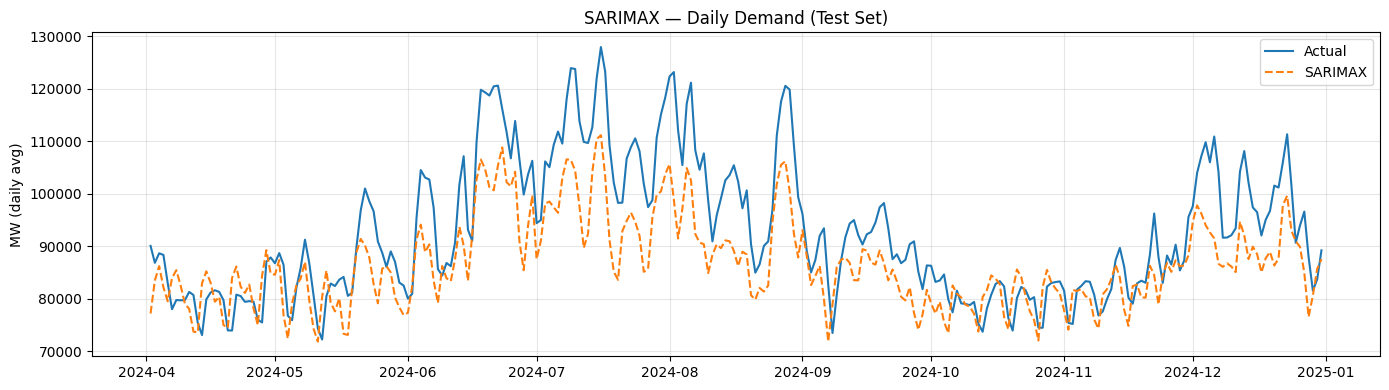

In [ ]:
plt.figure()
plt.plot(test_d.index, test_d['demand_mw'], label='Actual')
plt.plot(test_d.index, test_pred_d, label='SARIMAX', ls='--')
plt.title('SARIMAX — Daily Demand (Test Set)')
plt.ylabel('MW (daily avg)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. XGBoost without 1hr_lag
Full hourly feature matrix. No scaling needed for tree models.

In [ ]:
import xgboost as xgb
FEATURES_24H = [c for c in FEATURES if c != 'demand_lag_1h' and c != 'demand_forecast_mw']
print(FEATURES_24H)
X_train_24h = train[FEATURES_24H].values
X_val_24h   = val[FEATURES_24H].values
X_test_24h  = test[FEATURES_24H].values
X_train = train[FEATURES].values
y_train = train[TARGET].values
X_val   = val[FEATURES].values
y_val   = val[TARGET].values
X_test  = test[FEATURES].values
y_test  = test[TARGET].values

xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    early_stopping_rounds=100,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_24h, y_train,
    eval_set=[(X_val_24h, y_val)],
    verbose=200
)

print(f'Best iteration: {xgb_model.best_iteration}')

['temp_f', 'humidity_pct', 'wind_mph', 'cloud_pct', 'precip_in', 'hdd', 'cdd', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'wind_chill_f', 'demand_lag_24h', 'demand_lag_168h', 'temp_lag_24h', 'demand_rolling_24h_mean', 'temp_rolling_24h_mean', 'sin_year', 'cos_year', 'sin_half_year', 'cos_half_year', 'is_covid', 'lag24h_x_hdd', 'lag24h_x_cdd']
[0]	validation_0-rmse:13942.60916
[200]	validation_0-rmse:2430.69111
[400]	validation_0-rmse:2244.01252
[600]	validation_0-rmse:2185.98347
[800]	validation_0-rmse:2160.99110
[1000]	validation_0-rmse:2145.99323
[1200]	validation_0-rmse:2135.67369
[1400]	validation_0-rmse:2128.02937
[1600]	validation_0-rmse:2122.92026
[1800]	validation_0-rmse:2120.14553
[1999]	validation_0-rmse:2118.40533
Best iteration: 1998


In [ ]:
val_pred_xgb  = xgb_model.predict(X_val_24h)
test_pred_xgb = xgb_model.predict(X_test_24h)

results.append(evaluate('XGBoost', y_val,  val_pred_xgb,  'val'))
results.append(evaluate('XGBoost', y_test, test_pred_xgb, 'test'))

[XGBoost] val    MAPE=1.61%  RMSE=2,118 MW  MAE=1,518 MW
[XGBoost] test   MAPE=1.77%  RMSE=2,268 MW  MAE=1,677 MW


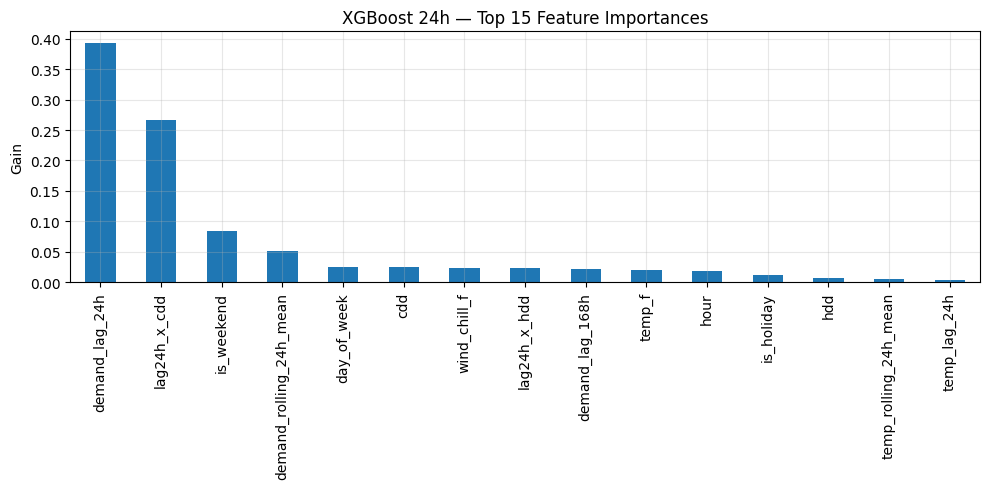

In [ ]:

xgb_model.get_booster().feature_names = FEATURES_24H[:len(xgb_model.feature_importances_)]

importance = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURES_24H[:len(xgb_model.feature_importances_)]
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.head(15).plot(kind='bar')
plt.title('XGBoost 24h — Top 15 Feature Importances')
plt.ylabel('Gain')
plt.tight_layout()
plt.show()

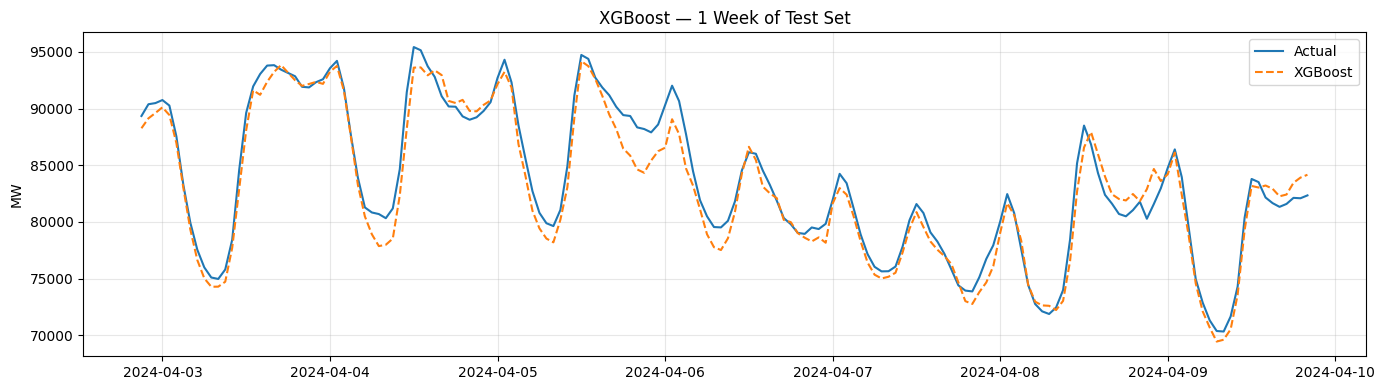

In [ ]:
# One week of test predictions
sample_idx = slice(0, 168)
plt.figure()
plt.plot(test['datetime_utc'].iloc[sample_idx], y_test[sample_idx], label='Actual', lw=1.5)
plt.plot(test['datetime_utc'].iloc[sample_idx], test_pred_xgb[sample_idx], label='XGBoost', lw=1.5, ls='--')
plt.title('XGBoost — 1 Week of Test Set')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

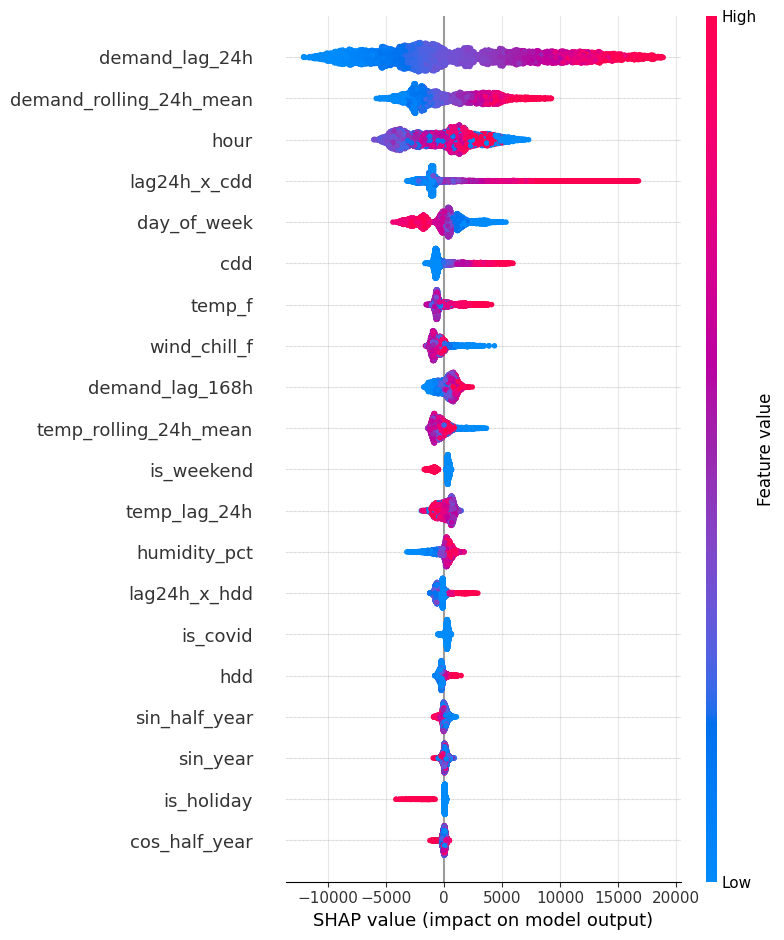

In [ ]:
import shap

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_24h)

shap.summary_plot(shap_values, X_test_24h, feature_names=FEATURES_24H)

## 6. LSTM
Sliding window of 168 hours (1 week) → predict next hour's demand.  
Features are scaled; target is normalized by train mean/std for stable gradients.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

WINDOW = 168   # 1 week lookback
BATCH  = 256
EPOCHS = 100

# Scale features
scaler_X = StandardScaler()
scaler_X.fit(X_train_24h)

# Normalize target by train stats (keeps units interpretable)
y_mean = y_train.mean()
y_std  = y_train.std()

X_train_s = scaler_X.transform(X_train_24h)
X_val_s   = scaler_X.transform(X_val_24h)
X_test_s  = scaler_X.transform(X_test_24h)

y_train_n = (y_train - y_mean) / y_std
y_val_n   = (y_val   - y_mean) / y_std

print(f'Scaled feature shape: {X_train_s.shape}')

Scaled feature shape: (30498, 25)


In [ ]:
def make_sequences(X, y, window):
    """Create sliding-window sequences for LSTM input."""
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# For val/test sequences we need the tail of the preceding split to build
# the first WINDOW context windows correctly.
X_tv = np.concatenate([X_train_s, X_val_s])
y_tv = np.concatenate([y_train_n, y_val_n])

X_seq_train, y_seq_train = make_sequences(X_train_s, y_train_n, WINDOW)

# Val sequences: use last WINDOW rows of train as context
X_tv_val = np.concatenate([X_train_s[-WINDOW:], X_val_s])
y_tv_val = np.concatenate([y_train_n[-WINDOW:], y_val_n])
X_seq_val, y_seq_val = make_sequences(X_tv_val, y_tv_val, WINDOW)

# Test sequences: use last WINDOW rows of val as context
y_test_n = (y_test - y_mean) / y_std
X_tv_test = np.concatenate([X_val_s[-WINDOW:], X_test_s])
y_tv_test = np.concatenate([y_val_n[-WINDOW:], y_test_n])
X_seq_test, y_seq_test = make_sequences(X_tv_test, y_tv_test, WINDOW)

print(f'Train sequences: {X_seq_train.shape}')
print(f'Val sequences:   {X_seq_val.shape}')
print(f'Test sequences:  {X_seq_test.shape}')

Train sequences: (30330, 168, 25)
Val sequences:   (6536, 168, 25)
Test sequences:  (6536, 168, 25)


In [ ]:
n_features = X_seq_train.shape[2]

lstm_model = Sequential([
    LSTM(128, input_shape=(WINDOW, n_features), return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        78,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,369 (509.25 KB)

 Trainable params: 130,369 (509.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

history = lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 0.1434 - val_loss: 0.0472 - learning_rate: 0.0010
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0392 - val_loss: 0.0291 - learning_rate: 0.0010
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0295 - val_loss: 0.0249 - learning_rate: 0.0010
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0247 - val_loss: 0.0206 - learning_rate: 0.0010
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0225 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0208 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0197 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0188 - val_loss: 0.0207 - learning_rate: 0.0010
Epoch 9/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0176
Epoch 9: ReduceLROnPlateau reducing

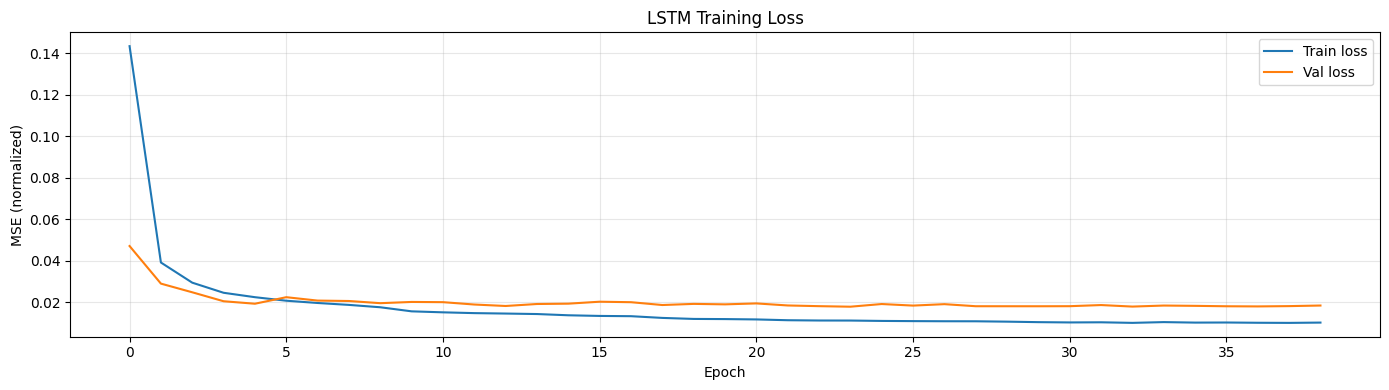

In [ ]:
# Training curve
plt.figure()
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalized)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Predict and inverse-normalize
val_pred_lstm  = lstm_model.predict(X_seq_val,  batch_size=BATCH, verbose=0).flatten() * y_std + y_mean
test_pred_lstm = lstm_model.predict(X_seq_test, batch_size=BATCH, verbose=0).flatten() * y_std + y_mean

results.append(evaluate('LSTM', y_val,  val_pred_lstm,  'val'))
results.append(evaluate('LSTM', y_test, test_pred_lstm, 'test'))

[LSTM] val    MAPE=1.57%  RMSE=2,047 MW  MAE=1,469 MW
[LSTM] test   MAPE=1.67%  RMSE=2,187 MW  MAE=1,584 MW


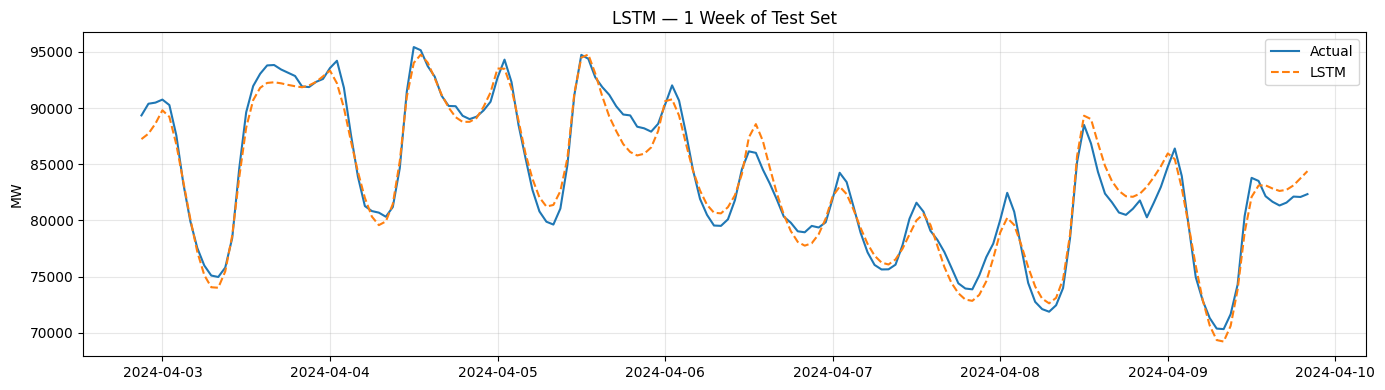

In [ ]:
sample_idx = slice(0, 168)
plt.figure()
plt.plot(test['datetime_utc'].iloc[sample_idx], y_test[sample_idx], label='Actual', lw=1.5)
plt.plot(test['datetime_utc'].iloc[sample_idx], test_pred_lstm[sample_idx], label='LSTM', lw=1.5, ls='--')
plt.title('LSTM — 1 Week of Test Set')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Model Comparison

In [ ]:
results_df = pd.DataFrame(results)
test_results = results_df[results_df['split'] == 'test'].set_index('model')[['MAPE', 'RMSE', 'MAE']]
test_results = test_results.sort_values('MAPE')

print('TEST SET RESULTS')
print(test_results.to_string())

print("Note: AIC/BIC (shown in SARIMAX section) compare SARIMAX orders only.")
print("      MAPE/RMSE above are the correct cross-model comparison metrics.")

=== TEST SET RESULTS ===
                     MAPE          RMSE          MAE
model                                               
LSTM             1.665805   2187.004228  1583.965234
XGBoost          1.768391   2268.491680  1677.414319
SARIMAX (daily)  7.507070   9129.956806  7368.409606
Persistence      9.117731  12221.782338  8828.007038
Note: AIC/BIC (shown in SARIMAX section) compare SARIMAX orders only.
      MAPE/RMSE above are the correct cross-model comparison metrics.


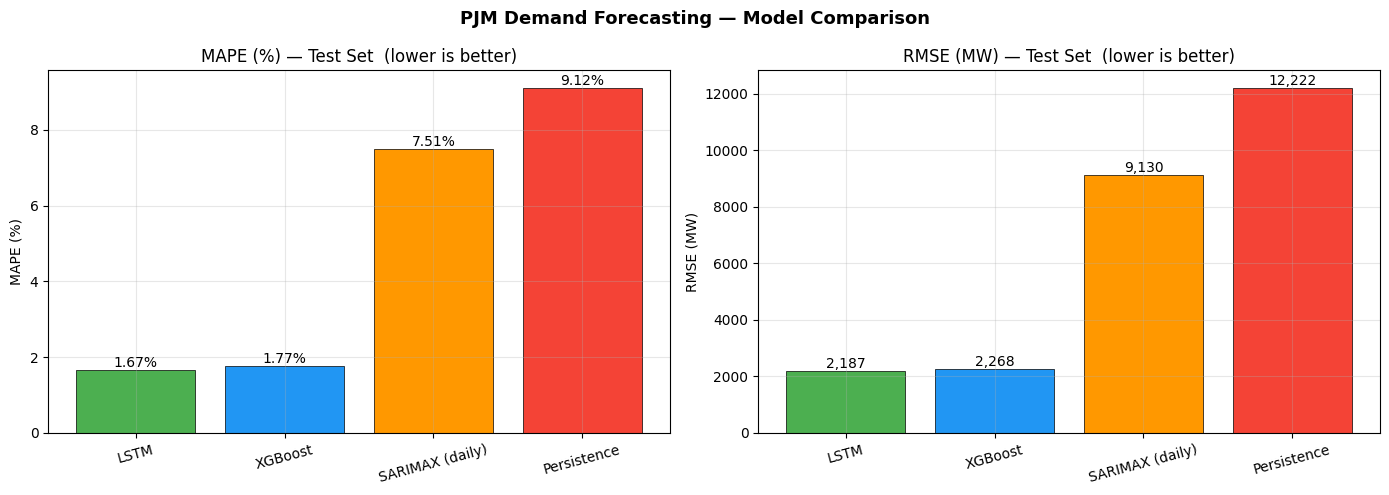

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# test_results already exists from cell 34, sorted by MAPE ascending
# Index: ['LSTM', 'XGBoost', 'SARIMAX (daily)', 'Persistence']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = test_results.index.tolist()
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']  # green, blue, orange, red

# --- MAPE panel ---
mape_vals = test_results['MAPE'].values
bars1 = axes[0].bar(models, mape_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('MAPE (%) — Test Set  (lower is better)', fontsize=12)
axes[0].set_ylabel('MAPE (%)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, mape_vals):
    axes[0].annotate(f'{val:.2f}%',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

# --- RMSE panel ---
rmse_vals = test_results['RMSE'].values
bars2 = axes[1].bar(models, rmse_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('RMSE (MW) — Test Set  (lower is better)', fontsize=12)
axes[1].set_ylabel('RMSE (MW)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, rmse_vals):
    axes[1].annotate(f'{val:,.0f}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.suptitle('PJM Demand Forecasting — Model Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

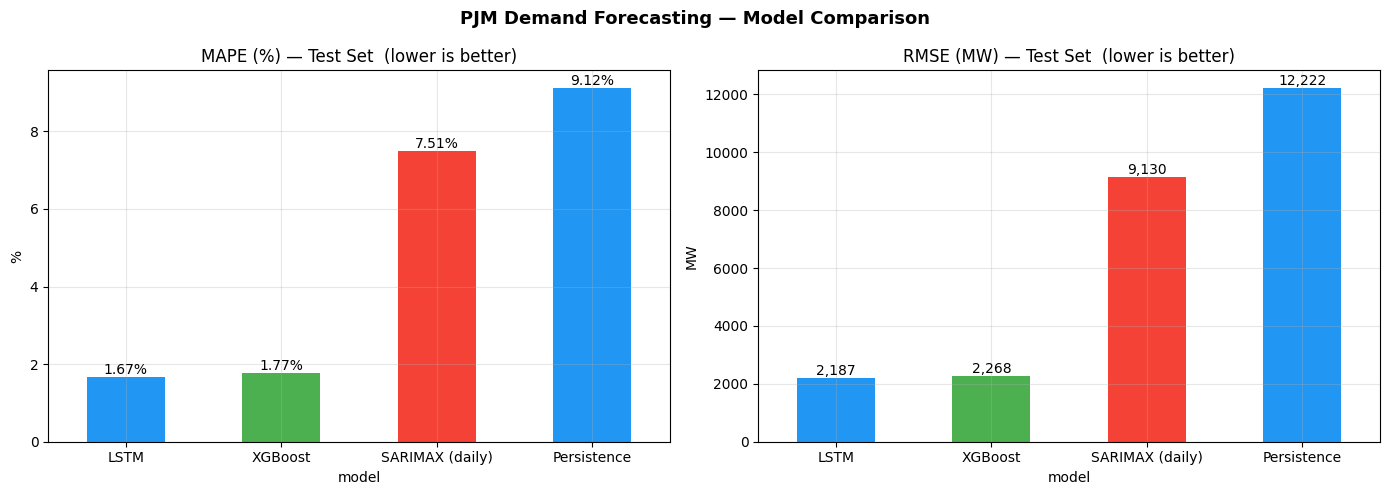

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

test_results['MAPE'].plot(kind='bar', ax=axes[0], color=['#2196F3', '#4CAF50', '#F44336'])
axes[0].set_title('MAPE (%) — Test Set  (lower is better)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

test_results['RMSE'].plot(kind='bar', ax=axes[1], color=['#2196F3', '#4CAF50', '#F44336'])
axes[1].set_title('RMSE (MW) — Test Set  (lower is better)')
axes[1].set_ylabel('MW')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.suptitle('PJM Demand Forecasting — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

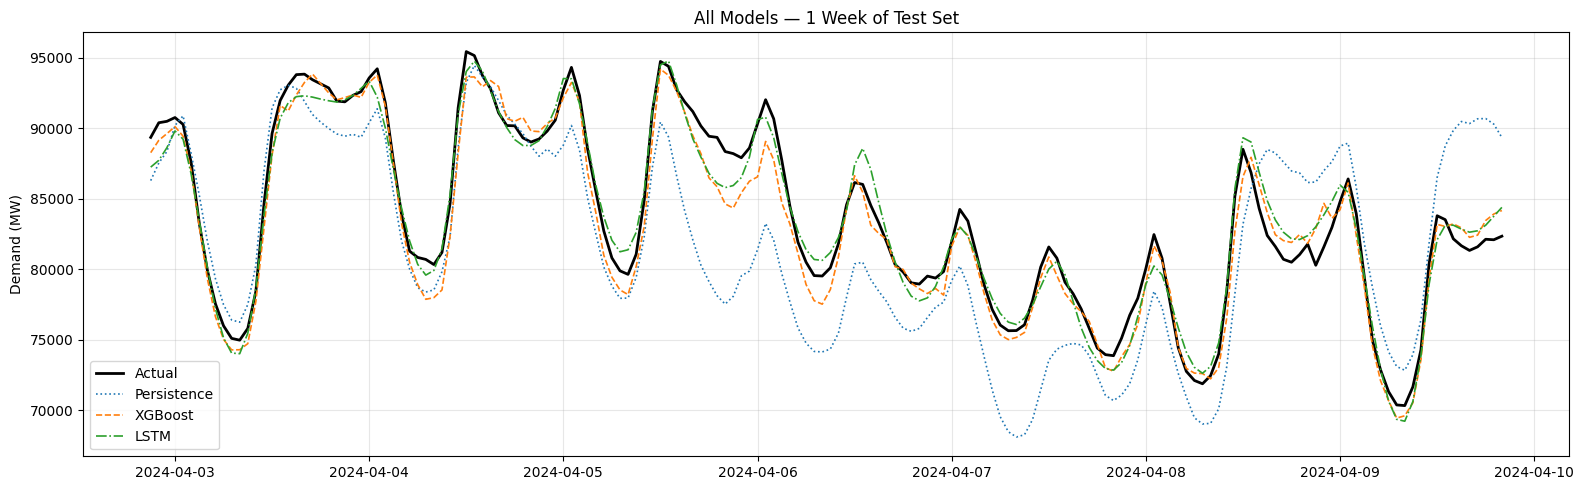

In [ ]:
# Overlay all models on same test week
s = slice(0, 168)
t = test['datetime_utc'].iloc[s]

plt.figure(figsize=(16, 5))
plt.plot(t, y_test[s],                              label='Actual',      lw=2, color='black')
plt.plot(t, test['demand_lag_168h'].iloc[s].values, label='Persistence', lw=1.2, ls=':')
plt.plot(t, test_pred_xgb[s],                       label='XGBoost',     lw=1.2, ls='--')
plt.plot(t, test_pred_lstm[s],                      label='LSTM',        lw=1.2, ls='-.')
plt.title('All Models — 1 Week of Test Set')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

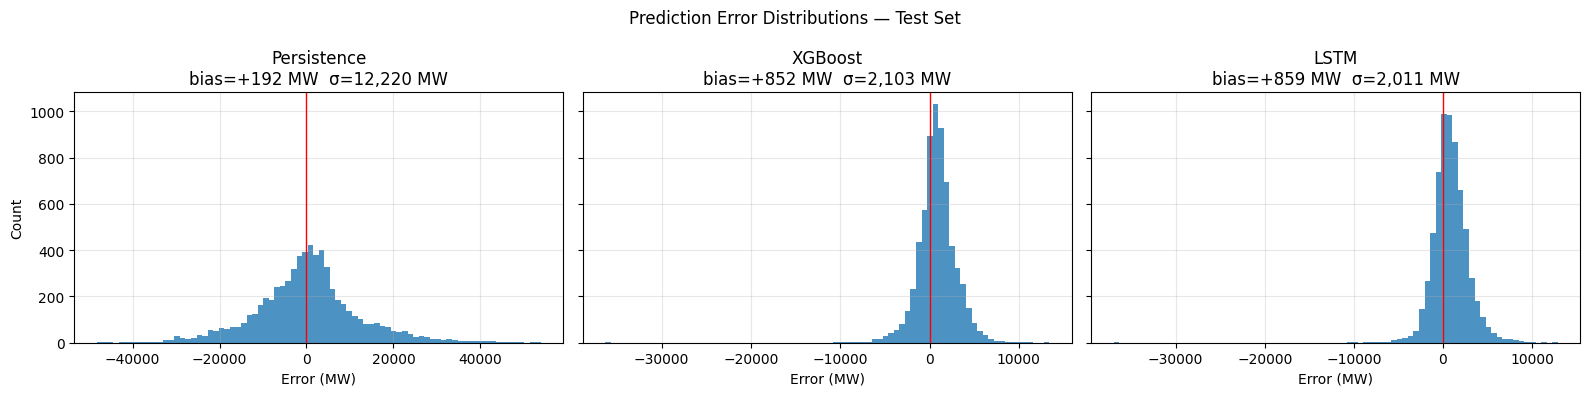

In [ ]:
# Error distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (name, preds) in zip(axes, [
    ('Persistence', test['demand_lag_168h'].values),
    ('XGBoost',     test_pred_xgb),
    ('LSTM',        test_pred_lstm),
]):
    errors = y_test - preds
    ax.hist(errors, bins=80, edgecolor='none', alpha=0.8)
    ax.axvline(0, color='red', lw=1)
    ax.set_title(f'{name}\nbias={errors.mean():+,.0f} MW  σ={errors.std():,.0f} MW')
    ax.set_xlabel('Error (MW)')

axes[0].set_ylabel('Count')
plt.suptitle('Prediction Error Distributions — Test Set', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
PRICE_PER_MWH = 33.74  # $/MWh — adjust to real PJM price if you have it

models = {
    'Persistence': test['demand_lag_168h'].values,
    'XGBoost':     test_pred_xgb,
    'LSTM':        test_pred_lstm,
}

print('ESTIMATED COST OF FORECAST ERROR')
for name, preds in models.items():
    avg_mw_error = np.abs(y_test - preds).mean()
    hourly_cost  = avg_mw_error * PRICE_PER_MWH
    annual_cost  = hourly_cost * 8760
    print(f'{name:12s}  avg error={avg_mw_error:,.0f} MW  '
          f'~${hourly_cost:,.0f}/hr  ~${annual_cost/1e6:.1f}M/year')

=== ESTIMATED COST OF FORECAST ERROR ===
Persistence   avg error=8,828 MW  ~$297,857/hr  ~$2609.2M/year
XGBoost       avg error=1,677 MW  ~$56,596/hr  ~$495.8M/year
LSTM          avg error=1,584 MW  ~$53,443/hr  ~$468.2M/year
